# Laboratory #4: Adversarial Learning and OOD Detection

In this laboratory session we will develop a methodology for detecting OOD samples and measuring the quality of OOD detection. We will also experiment with incorporating adversarial examples during training to render models more robust to adversarial attacks.

---
## Exercise 1: OOD Detection and Performance Evaluation
In this first exercise you will build a simple OOD detection pipeline and implement some performance metrics to evaluate its performance.

### Exercise 1.1: Build a simple OOD detection pipeline

Implement an OOD detection pipeline (like in the Flipped Activity notebook) using an ID and an OOD dataset of your choice. Some options:

+ CIFAR-10 (ID), Subset of CIFAR-100 (OOD). You will need to wrap CIFAR-100 in some way to select a subset of classes that are *not* in CIFAR-10 (see `torch.utils.data.Subset`).
+ Labeled Faces in the Wild (ID), CIFAR-10 or FakeData (OOD). The LfW dataset is available in Scikit-learn (see `sklearn.datasets.fetch_lfw_people`).
+ Something else, but if using images keep the images reasonably small!

In this exercise your *OOD Detector* should produce a score representing how "out of distribution" a test sample is. We will implement some metrics in the next exercise, but for now use the techniques from the flipped activity notebook to judge how well OOD scoring is working (i.e. histograms).

**Note**: Make sure you make a validation split of your ID dataset for testing.

In [1]:
import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
import torch
import torchvision
import matplotlib.pyplot as plt
import torch.nn.functional as F
import random
import numpy as np

from torchvision.transforms import v2 as v2
from torchvision.datasets import FakeData
from torch.utils.data import DataLoader
from torch import nn
from torch import optim
from sklearn import metrics
from omegaconf import OmegaConf
from tqdm import tqdm

Imposto tutti i seed necessari:

In [2]:
seed = 1302
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True

Definisco un dict di configurazione attraverso `OmegaConf`:

In [3]:
initial_config = OmegaConf.create({
    'mean': (0.5, 0.5, 0.5),
    'std': (0.5, 0.5, 0.5),
    'batch_size': 1024,
    'num_classes': 10,
    'num_workers': 8,
    'size': 1000,
    'image_size': (3, 32, 32)
})

Definisco la trasformazione da fare e successivamente:

1. CIFAR-10: Training set, test set e rispettivi DataLoaders.
2. FakeData: Dataset generato casualmente.

In [4]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=initial_config.mean, std=initial_config.std)
])

training_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_dl = DataLoader(training_set, batch_size=initial_config.batch_size, shuffle=True, num_workers=initial_config.num_workers)
test_dl = DataLoader(test_set, batch_size=initial_config.batch_size, shuffle=False, num_workers=initial_config.num_workers)

fake_set = FakeData(size=initial_config.size, image_size=initial_config.image_size, num_classes=initial_config.num_classes, transform=transform)
fake_dl = DataLoader(fake_set, batch_size=initial_config.batch_size, shuffle=False, num_workers=initial_config.num_workers)

Definisco una classe `NormalizeInverse` che de-normalizza le immagini:

In [5]:
class NormalizeInverse(torchvision.transforms.Normalize):
    def __init__(self, mean, std):
        mean = torch.tensor(mean)
        std = torch.tensor(std)
        std_inv = 1.0 / (std + 1.0e-7)
        mean_inv = -mean * std_inv
        super().__init__(mean_inv, std_inv)

    def __call__(self, tensor):
        return super().__call__(tensor.clone())
    
inv_normalize = NormalizeInverse(mean=initial_config.mean, std=initial_config.std)

Di seguito due esempi esplicativi di differenza tra immagine normalizzata e non normalizzata, sia nel caso di CIFAR-10 che di FakeData:

Batch of images shape: torch.Size([1024, 3, 32, 32])
Batch of labels shape: torch.Size([1024])


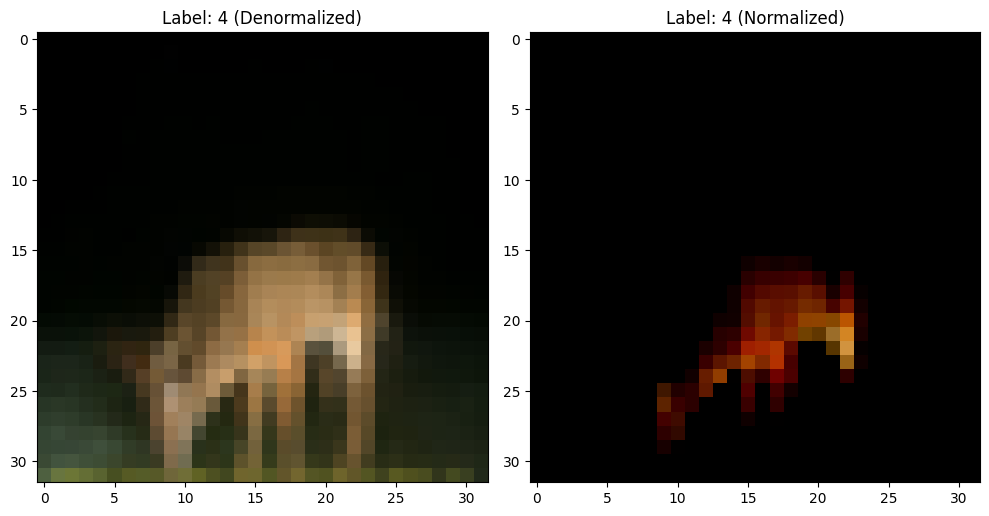

Batch of images shape: torch.Size([1024, 3, 32, 32])
Batch of labels shape: torch.Size([1024])


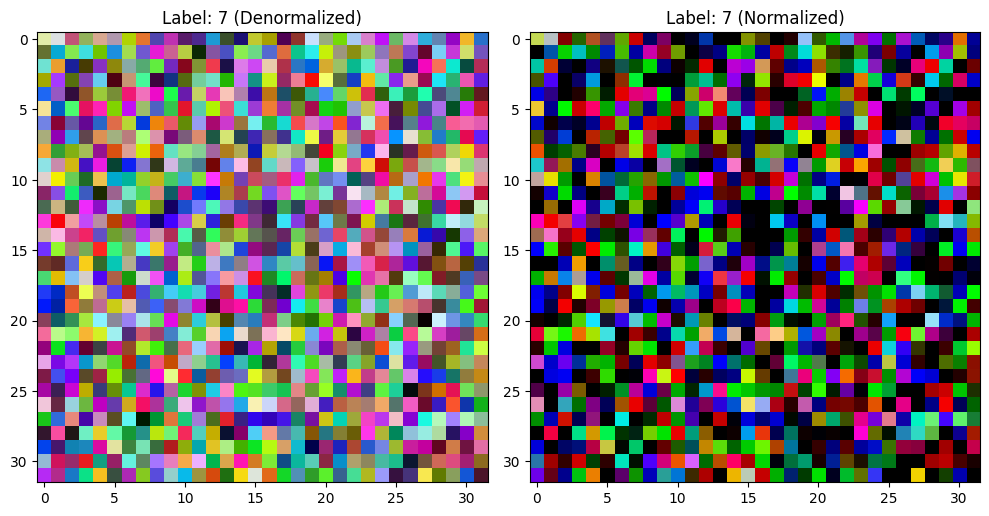

In [6]:
for images, labels in train_dl:
    print(f"Batch of images shape: {images.shape}")
    print(f"Batch of labels shape: {labels.shape}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(inv_normalize(images[0, :]).permute(1, 2, 0).clamp(0, 1))
    axes[1].imshow(images[0, :].permute(1, 2, 0).clamp(0, 1))
    axes[0].set_title(f"Label: {labels[0].item()} (Denormalized)")
    axes[1].set_title(f"Label: {labels[0].item()} (Normalized)")
    plt.tight_layout()
    plt.show()
    break

for fake_images, fake_labels in fake_dl:
    print(f"Batch of images shape: {images.shape}")
    print(f"Batch of labels shape: {labels.shape}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(inv_normalize(fake_images[0, :]).permute(1, 2, 0).clamp(0, 1))
    axes[1].imshow(fake_images[0, :].permute(1, 2, 0).clamp(0, 1))
    axes[0].set_title(f"Label: {fake_labels[0].item()} (Denormalized)")
    axes[1].set_title(f"Label: {fake_labels[0].item()} (Normalized)")
    plt.tight_layout()
    plt.show()
    break

Salvo in un dizionario le varie classi associate ai rispettivi indici:

In [7]:
class_dict = {class_name:id_class for id_class, class_name in enumerate(training_set.classes)}
print(class_dict)

{'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


Definisco una CNN che userò negli attacchi adversarial:

In [8]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=2, padding=1)
        self.conv5 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=2, padding=1)

        self.flatten_dim = 512 * 8 * 8
        self.fc1 = nn.Linear(self.flatten_dim, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = torch.flatten(x, 1) # (batch_size, 512, 8, 8) -> (batch_size, 512*8*8)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

Istanzio un altro dizionario di configurazione con `OmegaConf` che mi servirà per l'addestramento della CNN:

In [9]:
cnn_config = OmegaConf.create({
    'lr': 0.001,
    'num_epochs': 30,
})

Di seguito istanzio:
1. Device
2. Modello (CNN)
3. Loss function
4. Ottimizzatore

In [195]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN()

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=cnn_config.lr)

Di seguito un loop di training:

100%|██████████| 49/49 [00:06<00:00,  8.15it/s]


Epoch [1/30], Loss: 2.0047


100%|██████████| 49/49 [00:06<00:00,  8.17it/s]


Epoch [2/30], Loss: 1.5301


100%|██████████| 49/49 [00:05<00:00,  8.19it/s]


...

Epoch [28/30], Loss: 0.0151


100%|██████████| 49/49 [00:05<00:00,  8.23it/s]


Epoch [29/30], Loss: 0.0185


100%|██████████| 49/49 [00:06<00:00,  8.09it/s]

Epoch [30/30], Loss: 0.0172


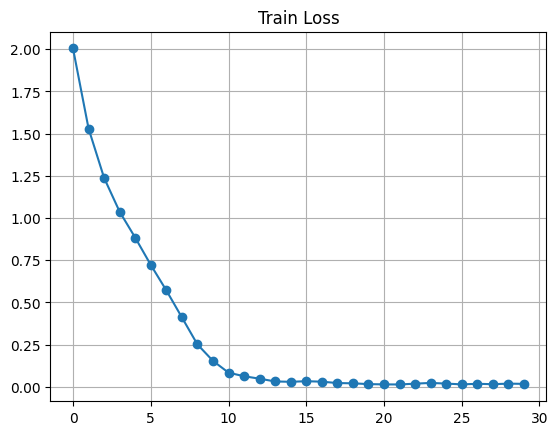

In [196]:
model = model.to(device)
avg_training_losses = []

for epoch in range(cnn_config.num_epochs):
    model.train()
    train_loss = 0.0
    for (images, labels) in tqdm(train_dl):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_dl)
    avg_training_losses.append(avg_train_loss)

    print(f"Epoch [{epoch+1}/{cnn_config.num_epochs}], Loss: {avg_train_loss:.4f}")

plt.plot(avg_training_losses, marker='o', linestyle='-')
plt.title('Train Loss')
plt.grid(True)

Di seguito la valutazione del modello:

In [197]:
model.eval()
y_gt, y_pred = [], []
with torch.no_grad():
    for (images, labels) in tqdm(test_dl):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        y_gt.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

y_gt = torch.tensor(y_gt)
y_pred = torch.tensor(y_pred)

accuracy = metrics.accuracy_score(y_gt, y_pred)
print(f'Test Accuracy: {100* accuracy:.3f}%')

model = model.to('cpu')

100%|██████████| 10/10 [00:00<00:00, 14.73it/s]

Test Accuracy: 69.370%


L'accuratezza è molto bassa. 

Genero anche una matrice di confusione per avere un risultato visivo:

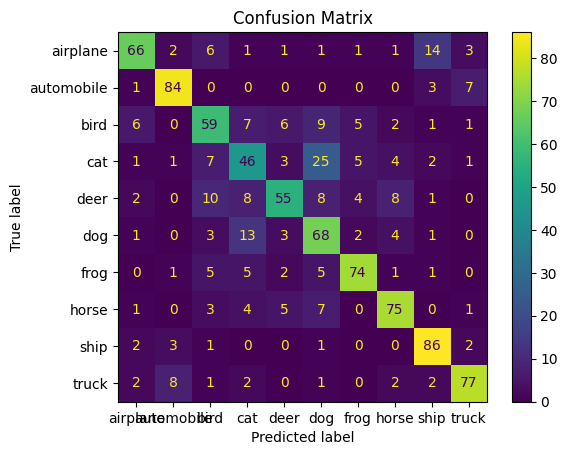

In [198]:
conf_matrix = metrics.confusion_matrix(y_gt, y_pred)
conf_matrix = conf_matrix.astype(np.float32) 
conf_matrix /= conf_matrix.sum(axis=1, keepdims=True)
conf_matrix = (100 * conf_matrix).astype(np.int32)

display_ = metrics.ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=test_set.classes)
display_.plot()
plt.title("Confusion Matrix")
plt.show()

In [199]:
print(f'Per class accuracy: {np.diag(conf_matrix).mean():.3f}%')

Per class accuracy: 69.000%


Di seguito definisco una funzione che mostra la confidenza del modello nelle predizioni in termini di logits:

In [241]:
def plot_logits_and_softmax(model, images, labels, device, k, temperature, test_set=None):
    model = model.to(device)
    outputs = model(images.to(device))
    pred = outputs[k].detach().cpu()
    pred_max = pred.argmax().item()
    if test_set is not None:
        print(f'GT: {test_set.classes[labels[k]]} ({class_dict[test_set.classes[labels[k]]]}), Pred: {test_set.classes[pred_max]} ({class_dict[test_set.classes[pred_max]]})') # La label corrispondente

    fig, ax = plt.subplots(1, 3, figsize=(15, 7))

    ax[0].bar(np.arange(10), pred)
    ax[0].set_title('Logit')
    ax[1].bar(np.arange(10), F.softmax(pred / temperature, dim=0))
    ax[1].set_title(f'Softmax with Temperature = {temperature}')
    ax[2].imshow(inv_normalize(images[k, :].cpu()).permute(1, 2, 0).clamp(0, 1))
    ax[2].set_title('Input Image')
    plt.show()
    model = model.to('cpu')

Original Image with Logits and Softmax
GT: cat (3), Pred: dog (5)


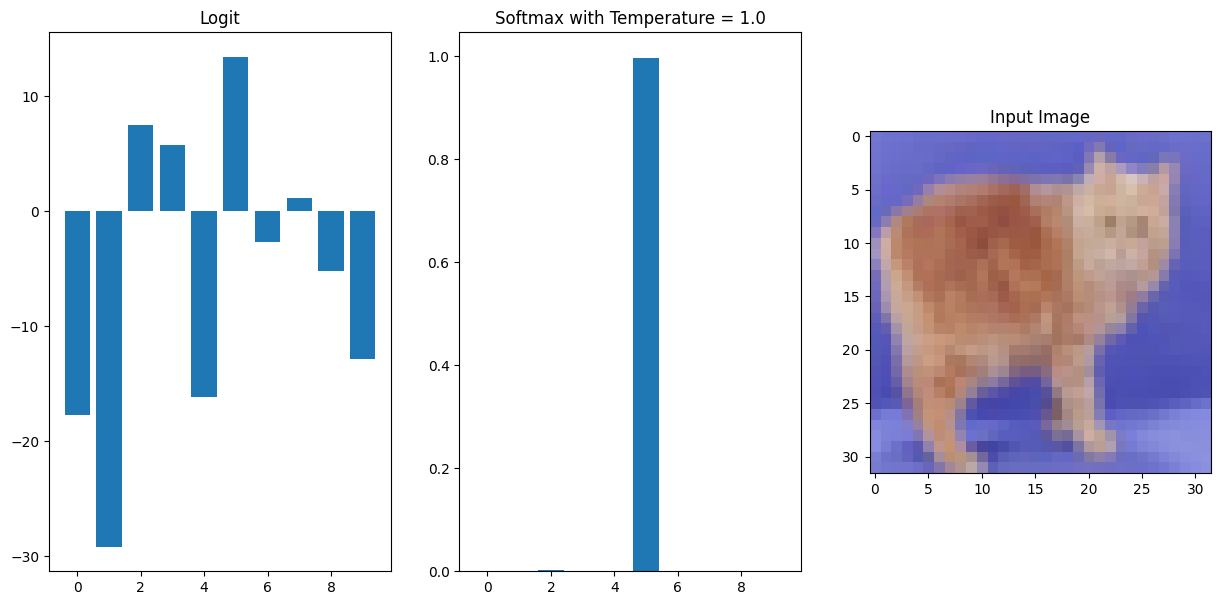

Fake Image with Logits and Softmax


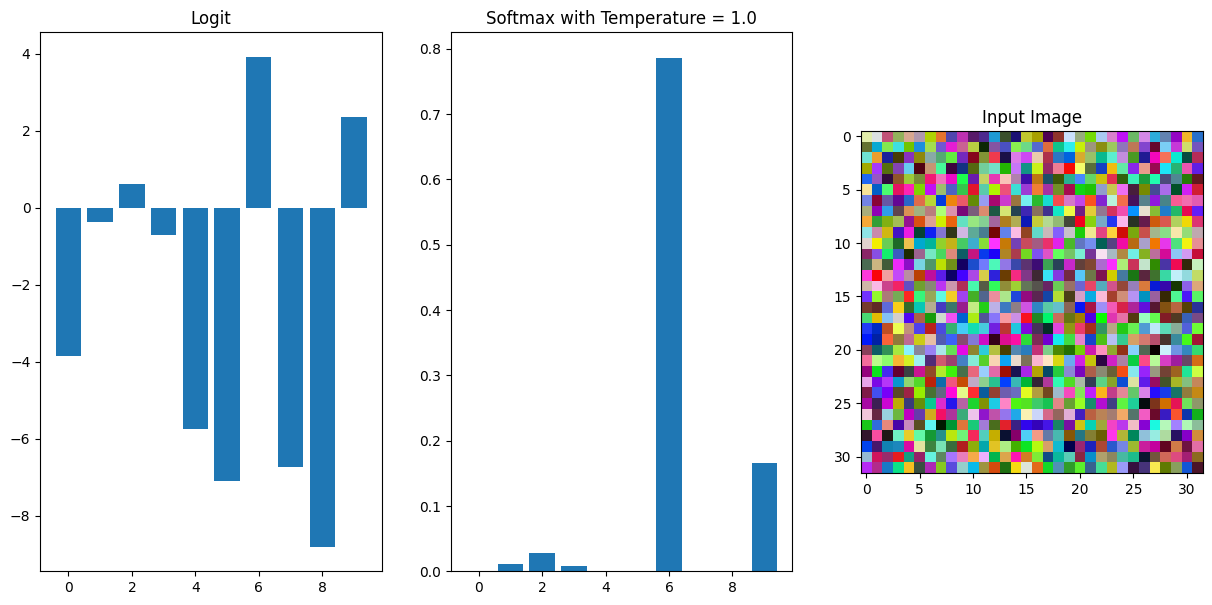

In [242]:
print('Original Image with Logits and Softmax')
plot_logits_and_softmax(model, images, labels, device, k=random.randint(0, images.shape[0] - 1), temperature=1.0, test_set=test_set)

print('Fake Image with Logits and Softmax')
plot_logits_and_softmax(model, fake_images, fake_labels, device, k=0, temperature=1.0)
        

Di seguito tre funzioni:

1. `max_logit()`, che restituisce il logit più alto.
2. `max_softmax()`, che restituisce il valore più alto della Softmax.
3. `compute_scores`, che viene utilizzata per calcolare una delle prime due funzioni su un dataloader.

In [17]:
def max_logit(logit):
    return logit.max(dim=1)[0]

def max_softmax(logit, temperature=1):
    return F.softmax(logit / temperature, dim=1).max(dim=1)[0]

def compute_scores(model, device, dataloader, score_function):
    scores = []
    model = model.to(device)
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            outputs = model(images)
            batch_scores = score_function(outputs)
            scores.extend(batch_scores.cpu().numpy())
    model = model.to('cpu')
    return torch.tensor(scores)

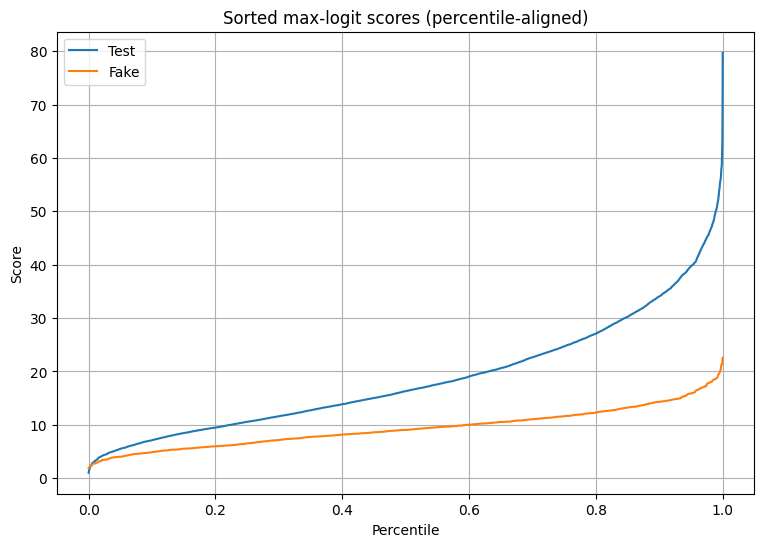

In [240]:
scores_test = compute_scores(model, device, test_dl, max_logit)
scores_fake = compute_scores(model, device, fake_dl, max_logit)

test_sorted = np.sort(scores_test.cpu().numpy())
fake_sorted = np.sort(scores_fake.cpu().numpy())

test_x = np.linspace(0, 1, len(test_sorted))
fake_x = np.linspace(0, 1, len(fake_sorted))

plt.figure(figsize=(9, 6))
plt.plot(test_x, test_sorted, label='Test')
plt.plot(fake_x, fake_sorted, label='Fake')
plt.title('Sorted max-logit scores (percentile-aligned)')
plt.legend()
plt.xlabel('Percentile')
plt.ylabel('Score')
plt.grid(True)
plt.show()

Il grafico mostra che i max-logit dei dati reali (CIFAR-10) sono, in generale, molto maggiori di quelli di FakeData.

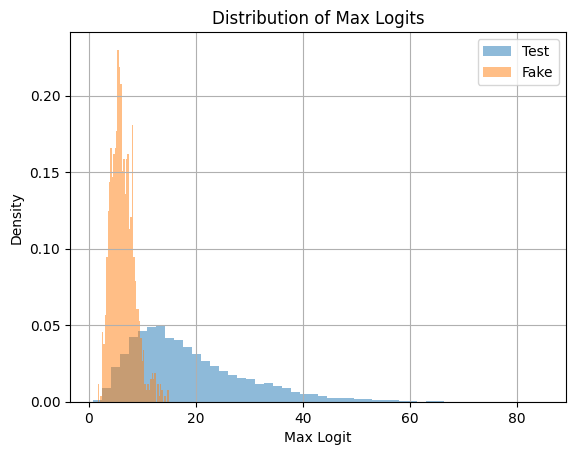

In [19]:
plt.hist(scores_test, density=True, bins=50, alpha=0.5, label='Test')
plt.hist(scores_fake, density=True, bins=50, alpha=0.5, label='Fake')
plt.legend()
plt.xlabel('Max Logit')
plt.ylabel('Density')
plt.title('Distribution of Max Logits')
plt.grid(True)
plt.show()

L'istogramma mostra che la rete è molto più sicura nel caso dei dati "Test" rispetto che nel caso dei dati "Fake" (logit molto più alti).


C'è una zona di sovrapposizione tra i due scenari, ma nel caso dei dati "Test", la distribuzione è molto più larga, con una coda a destra.

Definisco un Autoencoder:

In [20]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=12, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=12, out_channels=24, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=24, out_channels=48, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=48, out_channels=24, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=24, out_channels=12, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=12, out_channels=3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

Definisco un dizionario per il setting:

In [21]:
autoenc_config = OmegaConf.create({
    'lr': 0.0001,
    'num_epochs': 20
})

Istanzio:

1. Autoencoder
2. Loss function
3. Ottimizzatore

In [24]:
autoencoder = Autoencoder()

mse_loss = nn.MSELoss()
optimizer_autoenc = optim.Adam(autoencoder.parameters(), lr=autoenc_config.lr)

Training loop:

In [25]:
autoencoder = autoencoder.to(device)

for epoch in range(autoenc_config.num_epochs):
    autoencoder.train()
    train_loss = 0.0
    for (images, labels) in tqdm(train_dl):
        images = images.to(device)

        optimizer_autoenc.zero_grad()
        _, outputs = autoencoder(images)
        loss = mse_loss(outputs, images)
        loss.backward()
        optimizer_autoenc.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_dl)
    print(f"Epoch [{epoch+1}/{autoenc_config.num_epochs}], Loss: {avg_train_loss:.4f}")

100%|██████████| 49/49 [00:00<00:00, 63.33it/s]


Epoch [1/20], Loss: 0.2530


100%|██████████| 49/49 [00:00<00:00, 62.00it/s]


Epoch [2/20], Loss: 0.2360


100%|██████████| 49/49 [00:00<00:00, 68.00it/s]


...

Epoch [18/20], Loss: 0.0488


100%|██████████| 49/49 [00:00<00:00, 67.29it/s]


Epoch [19/20], Loss: 0.0465


100%|██████████| 49/49 [00:00<00:00, 65.26it/s]

Epoch [20/20], Loss: 0.0447


Valutazione del modello:

In [ ]:
autoencoder.eval()
val_loss = nn.MSELoss(reduction='none')
scores_fake_ae = []

with torch.no_grad():
    for (images, labels) in fake_dl:
        images = images.to(device)
        _, outputs = autoencoder(images)
        batch_loss = val_loss(outputs, images).mean(dim=[1, 2, 3])
        scores_fake_ae.extend(-batch_loss.cpu().numpy())
scores_fake_ae = torch.tensor(scores_fake_ae)

scores_test_ae = []
with torch.no_grad():
    for images, labels in test_dl:
        images = images.to(device)
        _, outputs = autoencoder(images)
        batch_loss = val_loss(outputs, images).mean(dim=[1, 2, 3])
        scores_test_ae.extend(-batch_loss.cpu().numpy())

scores_test_ae = torch.tensor(scores_test_ae)
autoencoder = autoencoder.to('cpu')

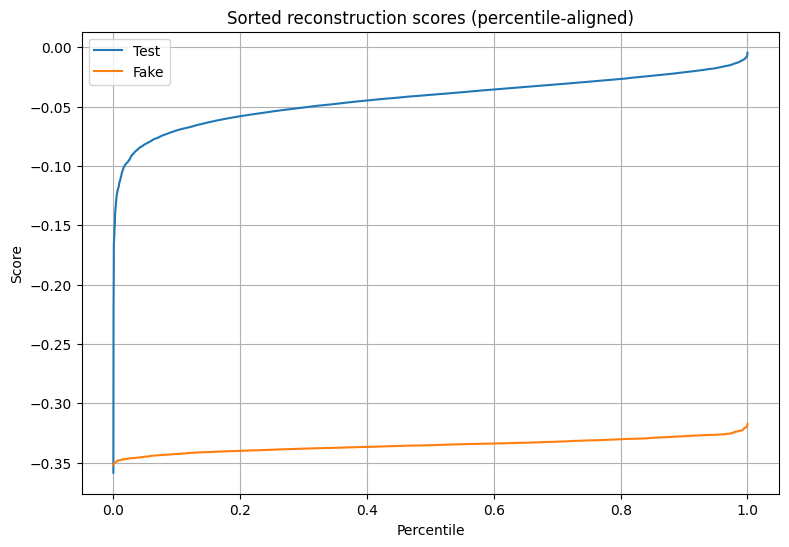

In [237]:
test_sorted = np.sort(scores_test_ae.cpu().numpy())
fake_sorted = np.sort(scores_fake_ae.cpu().numpy())

test_x = np.linspace(0, 1, len(test_sorted))
fake_x = np.linspace(0, 1, len(fake_sorted))

plt.figure(figsize=(9, 6))
plt.plot(test_x, test_sorted, label='Test')
plt.plot(fake_x, fake_sorted, label='Fake')
plt.title('Sorted reconstruction scores (percentile-aligned)')
plt.legend()
plt.xlabel('Percentile')
plt.ylabel('Score')
plt.grid(True)
plt.show()

Dal momento che lo score preso in considerazione è la loss cambiata di segno, il grafico sopra riportato mostra che l'autoencoder riesce efficacemente a distinguere immagini in-distribution e out-of-distribution.

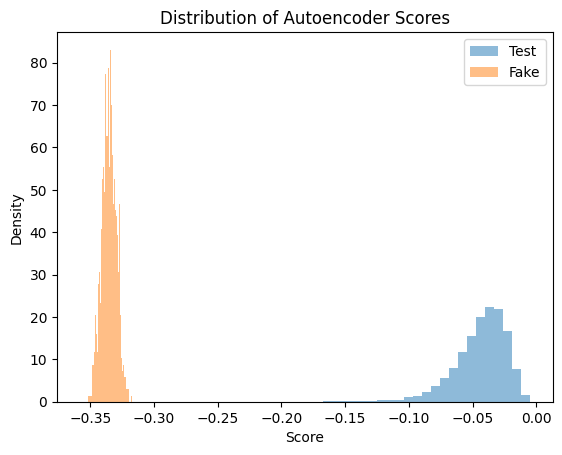

In [38]:
plt.hist(scores_test_ae.cpu(), density=True, bins=50, alpha=0.5, label='Test')
plt.hist(scores_fake_ae.cpu(), density=True, bins=50, alpha=0.5, label='Fake')
plt.legend()
plt.title('Distribution of Autoencoder Scores')
plt.xlabel('Score')
plt.ylabel('Density')
plt.show()

Questo secondo grafico conferma quanto riportato precedentemente.

### Exercise 1.2: Measure your OOD detection performance

There are several metrics used to evaluate OOD detection performance, we will concentrate on two threshold-free approaches: the area under the Receiver Operator Characteristic (ROC) curve for ID classification, and the area under the Precision-Recall curve for *both* ID and OOD scoring. See [the ODIN paper](https://arxiv.org/pdf/1706.02690.pdf) section 4.3 for a description of OOD metrics.

Use the functions in `sklearn.metrics` to produce ROC and PR curves for your OOD detector. Some useful functions:

+ [`sklearn.metric.RocCurveDisplay.from_predictions`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html)
+ [`sklearn.metrics.PrecisionRecallDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.PrecisionRecallDisplay.html)


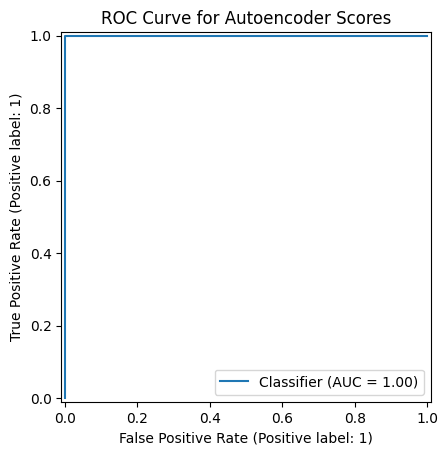

In [39]:
ypred = torch.cat((scores_test_ae, scores_fake_ae))
ytest = torch.ones_like(scores_test_ae)
yfake = torch.zeros_like(scores_fake_ae)

y = torch.cat((ytest, yfake))
metrics.RocCurveDisplay.from_predictions(y.cpu(), ypred.cpu())
plt.title('ROC Curve for Autoencoder Scores')
plt.show()

Il grafico sopra riportato mostra come l'autoencoder abbia prestazioni impeccabili.

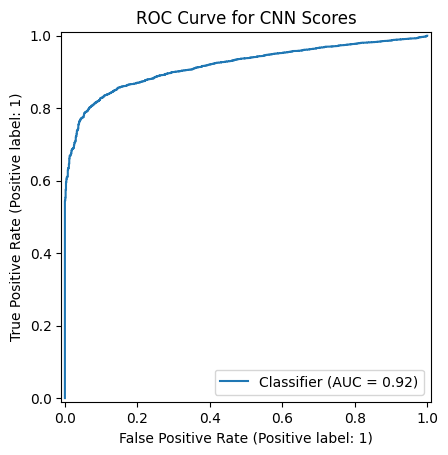

In [40]:
ypred = torch.cat((scores_test, scores_fake))
ytest = torch.ones_like(scores_test)
yfake = torch.zeros_like(scores_fake)

y = torch.cat((ytest, yfake))
metrics.RocCurveDisplay.from_predictions(y.cpu(), ypred.cpu())
plt.title('ROC Curve for CNN Scores')
plt.show()

La CNN ha delle prestazioni inferiori all'autoencoder in quanto può classificare il rumore con alta confidenza (producendo un max-logit alto).

---
## Exercise 2: Enhancing Robustness to Adversarial Attack

In this second exercise we will experiment with enhancing our base model to be (more) robust to adversarial attacks. 

### Exercise 2.1: Implement FGSM and generate adversarial examples

Recall that the Fast Gradient Sign Method (FGSM) perturbs samples in the direction of the gradient with respect to the input $\mathbf{x}$:
$$ \boldsymbol{\eta}(\mathbf{x}) = \varepsilon \mathrm{sign}(\nabla_{\mathbf{x}} \mathcal{L}(\boldsymbol{\theta}, \mathbf{x}, y)) ) $$
Implement FGSM and generate some *adversarial examples* using your trained ID model. Evaluate these samples qualitatively and quantitatively. Evaluate how dependent on $\varepsilon$ the quality of these samples are. 

In [41]:
for i, c in enumerate(test_set.classes):
    print(i, c)

0 airplane
1 automobile
2 bird
3 cat
4 deer
5 dog
6 frog
7 horse
8 ship
9 truck


Di seguito l'implementazione di FGSM:

In [60]:
def FGSM(model, image, label, epsilon, targeted=False, target_label=None):

    image = image.clone().detach().requires_grad_(True)
    output = model(image)
   
    if not targeted: 
        loss_label = label.detach().clone().view(-1).to(device)
     
    else:
        loss_label = torch.tensor([target_label]).to(device)
        
    loss = F.cross_entropy(output, loss_label)
    model.zero_grad()
    loss.backward()
    pert = epsilon * torch.sign(image.grad)

    if not targeted:
        adv_image = image + pert
    else:
        adv_image = image - pert

    with torch.no_grad():
        adv_pred = model(adv_image).argmax().item()
    
    return adv_image.detach(), adv_pred

Implementazione delle funzioni che effettueranno attacchi untargeted e targeted:

In [232]:
def untargeted_attack(model, eps=5.0/255.0, max_iters=1000, sample_id=0):

    model.eval()
    model = model.to(device)
    for i, (images, labels) in tqdm(enumerate(test_dl)):
        eps = 5.0/255.0
        image, label = images[sample_id].to(device), labels[sample_id].to(device)
        image, label = image.unsqueeze(0), label.unsqueeze(0)

        with torch.no_grad():
            output = model(image)

        if output.argmax().item() != label.item():
            print(f'Image {i} - Classifier is already wrong, skipping attack!\n')
        else:
            done = False
            print(f'Image {i} - Attack started!')
            n_iter = 0

            adv_image = image

            while not done and n_iter < max_iters:
                adv_image, index = FGSM(model=model, image=adv_image, label=label, epsilon=eps)
                n_iter += 1

                with torch.no_grad():
                    output = model(adv_image)
                    pred = output.argmax().item()

                if pred != label.item():
                    print(f'Untargeted attack success! Budget:{int(255*n_iter*eps)}/255\n')
                    done = True
            
            if not done:
                print(f'Image {i} - attack failed within {max_iters} iterations')

            if i%5 == 0:
                img = inv_normalize(adv_image.cpu()[0])
                plt.imshow(img.permute(1, 2, 0).clamp(0, 1))
                plt.title(test_set.classes[index])
                plt.show()


def targeted_attack(model, target_label, eps=5.0/255.0, max_iters=1000, sample_id=0):

    model.eval()
    model = model.to(device)
    for i, (images, labels) in tqdm(enumerate(test_dl)):
        image, label = images[sample_id].to(device), labels[sample_id].to(device)
        image, label = image.unsqueeze(0), label.unsqueeze(0)

        with torch.no_grad():
            output = model(image)

        if output.argmax().item() == target_label or label.item() == target_label:
            print(f'Image {i} - Classifier is already wrong or target label same as GT, skipping attack!\n')
        else:
            done = False
            print(f'Image {i} - Attack started!')
            n_iter = 0

            adv_image = image

            while not done and n_iter < max_iters:
                adv_image, index = FGSM(model=model, image=adv_image, label=label, epsilon=eps, targeted=True, target_label=target_label)
                n_iter += 1

                with torch.no_grad():
                    output = model(adv_image)
                    pred = output.argmax().item()

                if pred == target_label:
                    print(f'Targeted attack {test_set.classes[pred]} success! Budget:{int(255*n_iter*eps)}/255\n')
                    done = True
            
            if not done:
                print(f'Image {i} - attack failed within {max_iters} iterations')

            if i%5 == 0:
                img = inv_normalize(adv_image.cpu()[0])
                plt.imshow(img.permute(1, 2, 0).clamp(0, 1))
                plt.title(test_set.classes[index])
                plt.show()

### UNTARGETED ATTACK:

0it [00:00, ?it/s]

Image 0 - Attack started!
Untargeted attack success! Budget:5/255



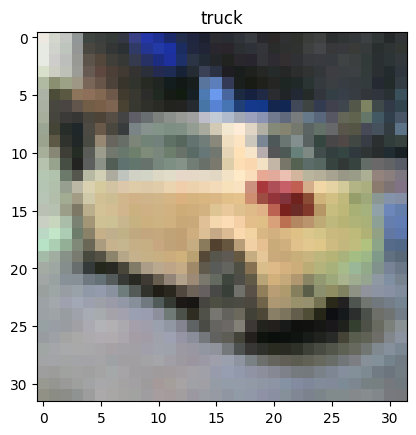

1it [00:00,  7.64it/s]

Image 1 - Classifier is already wrong, skipping attack!

Image 2 - Attack started!
Untargeted attack success! Budget:5/255

Image 3 - Attack started!
Untargeted attack success! Budget:5/255

Image 4 - Attack started!
Untargeted attack success! Budget:5/255

Image 5 - Attack started!
Untargeted attack success! Budget:10/255



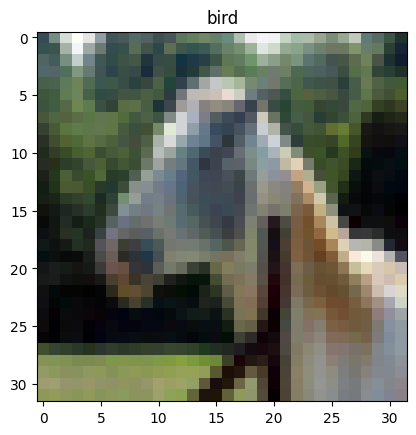

10it [00:00, 44.36it/s]

Image 6 - Attack started!
Untargeted attack success! Budget:10/255

Image 7 - Attack started!
Untargeted attack success! Budget:5/255

Image 8 - Attack started!
Untargeted attack success! Budget:10/255

Image 9 - Attack started!
Untargeted attack success! Budget:5/255



In [234]:
k = random.randint(0, initial_config.batch_size - 1)
untargeted_attack(model, sample_id=k)

### TARGETED ATTACK:

0it [00:00, ?it/s]

Image 0 - Attack started!
Targeted attack cat success! Budget:10/255



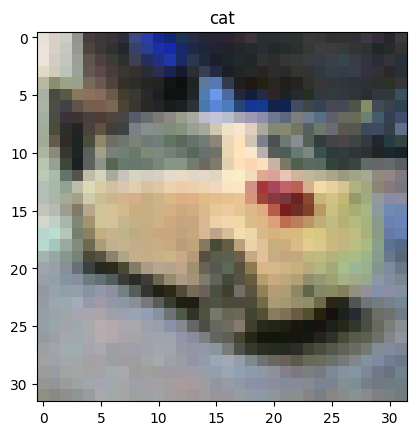

1it [00:00,  7.32it/s]

Image 1 - Classifier is already wrong or target label same as GT, skipping attack!

Image 2 - Attack started!
Targeted attack cat success! Budget:10/255

Image 3 - Attack started!
Targeted attack cat success! Budget:20/255

Image 4 - Attack started!
Targeted attack cat success! Budget:20/255

Image 5 - Attack started!
Targeted attack cat success! Budget:15/255



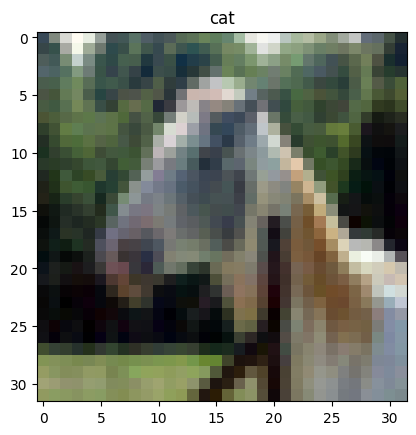

10it [00:00, 40.37it/s]

Image 6 - Attack started!
Targeted attack cat success! Budget:10/255

Image 7 - Attack started!
Targeted attack cat success! Budget:5/255

Image 8 - Attack started!
Targeted attack cat success! Budget:15/255

Image 9 - Attack started!
Targeted attack cat success! Budget:10/255



In [235]:
targeted_attack(model, class_dict['cat'], sample_id=k)

I risultati mostrano che in generale gli attacchi targeted sono più costosi di quelli untargeted.

### Exercise 2.2: Augment training with adversarial examples

Use your implementation of FGSM to augment your training dataset with adversarial samples. Ideally, you should implement this data augmentation *on the fly* so that the adversarial samples are always generated using the current model. Evaluate whether the model is more (or less) robust to ID samples using your OOD detection pipeline and metrics you implemented in Exercise 1.

In [78]:
config = OmegaConf.create({
    'num_epochs': 30,
    'eps': 5.0/255.0,
    'lr': 0.0001,
})

Definisco l'ottimizzatore:

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=config.lr)
new_model = model 

Training loop:

In [ ]:
for epoch in range(config.num_epochs):
    new_model.train()
    train_loss = 0.0
    for (images, labels) in tqdm(train_dl):
        images, labels = images.to(device), labels.to(device)
        images = images.clone().detach().requires_grad_(True)
        output = new_model(images)
        loss = F.cross_entropy(output, labels)

        new_model.zero_grad()
        loss.backward()

        adv_images = (images + config.eps * torch.sign(images.grad)).detach()

        optimizer.zero_grad()
        output = new_model(adv_images)
        loss = F.cross_entropy(output, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_dl)
    print(f"Epoch [{epoch+1}/{config.num_epochs}], Loss: {avg_train_loss:.4f}")

100%|██████████| 49/49 [00:11<00:00,  4.25it/s]


Epoch [1/30], Loss: 1.5295


100%|██████████| 49/49 [00:11<00:00,  4.27it/s]


Epoch [2/30], Loss: 0.7934


100%|██████████| 49/49 [00:11<00:00,  4.28it/s]


...

Epoch [28/30], Loss: 0.0014


100%|██████████| 49/49 [00:11<00:00,  4.27it/s]


Epoch [29/30], Loss: 0.0012


100%|██████████| 49/49 [00:11<00:00,  4.33it/s]

Epoch [30/30], Loss: 0.0009


In [ ]:
new_model.eval()
val_loss = 0.0
y_gt, y_pred = [], []
with torch.no_grad():
    for images, labels in test_dl:
        images, labels = images.to(device), labels.to(device)
        output = new_model(images)

        l = F.cross_entropy(output, labels)
        val_loss += l.item()

        y_gt.append(labels.cpu())
        y_pred.append(output.argmax(dim=1).cpu())
    
avg_val_loss = val_loss / len(test_dl)
print(f"Validation Loss: {avg_val_loss:.4f}")

Validation Loss: 4.2243


Test Accuracy: 70.690%


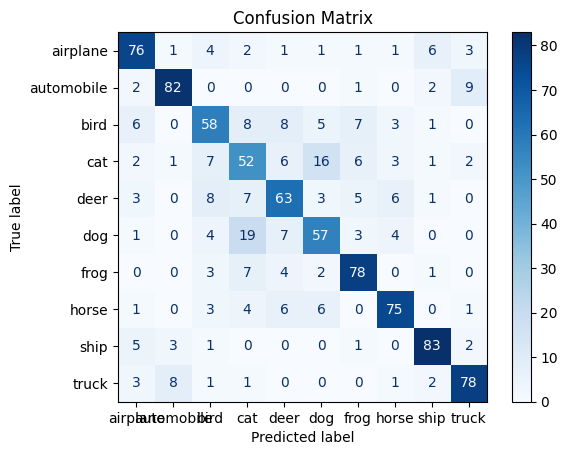

In [90]:
y_pred_tensor = torch.cat(y_pred)
y_gt_tensor = torch.cat(y_gt)

acc = sum(y_pred_tensor == y_gt_tensor) / len(y_gt_tensor)
print(f'Test Accuracy: {100* acc:.3f}%')

cmat = metrics.confusion_matrix(y_gt_tensor, y_pred_tensor)
cmat = cmat.astype(np.float32)
cmat /= cmat.sum(axis=1, keepdims=True)
cmat = (100 * cmat).astype(np.int32)
display_ = metrics.ConfusionMatrixDisplay(confusion_matrix=cmat, display_labels=test_set.classes)
display_.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [91]:
print('Per class accuracy: {:.3f}%'.format(np.diag(cmat).mean()))

Per class accuracy: 70.200%


L'accuratezza è migliorata circa del 2%.

### Exercise 3.3: Experiment with *targeted* adversarial attacks
Implement the targeted Fast Gradient Sign Method to generate adversarial samples that *imitate* samples from a specific class. Evaluate your adversarial samples qualitatively and quantitatively.


In [231]:
def targeted_FGSM_with_eval(model, target_label, dict_class, amplify=10, eps=5.0/255.0, plot=True):

    model.eval()

    N_total = 0
    N_clean_correct = 0
    N_adv_correct = 0
    N_attackable = 0
    N_success = 0

    sample = None

    model = model.to(device)
    for (images, labels) in (test_dl):
        images, labels = images.to(device), labels.to(device)
        batch_size = images.size(0)
        batch_target_label = torch.full((batch_size, ), target_label).to(device)
        N_total += batch_size

        with torch.no_grad():
            clean_output = model(images).argmax(dim=1)
        clean_correct = (clean_output == labels)
        N_clean_correct += clean_correct.sum().item()

        x = images.clone().detach().requires_grad_(True)
        output = model(x)
        loss = F.cross_entropy(output, batch_target_label)
        model.zero_grad()
        loss.backward()

        adv_images = (x - eps * x.grad.sign()).detach() 

        with torch.no_grad():
            adv_preds = model(adv_images).argmax(dim=1)

        adv_correct = (adv_preds == labels)
        N_adv_correct += adv_correct.sum().item()

        attackable = (clean_output != target_label) & (labels != target_label)
        success = attackable & (adv_preds == target_label)

        N_attackable += attackable.sum().item()
        N_success += success.sum().item()

        if sample is None and success.any():
            index = success.nonzero(as_tuple=True)[0][0].item()
            sample = (
                inv_normalize(images[index]).cpu(),
                inv_normalize(adv_images[index]).cpu(),
                clean_output[index].cpu().item(),
                adv_preds[index].cpu().item(),
                labels[index].cpu().item(),
            )

    clean_accuracy = N_clean_correct / N_total
    robust_accuracy = N_adv_correct / N_total
    asr = N_success / max(N_attackable, 1)

    if sample is not None and plot:
        clean_img, adv_img, clean_pred, adv_pred, gt = sample
        diff = adv_img - clean_img
        visualized_diff = (diff * amplify + 0.5)

        fig, ax = plt.subplots(1, 3, figsize=(13, 5))
        fig.subplots_adjust(wspace=0.5)
        ax[0].imshow(clean_img.permute(1, 2, 0).clamp(0, 1))
        ax[0].set_title(f'GT: {dict_class[gt]} - Pred label: {dict_class[clean_pred]}')

        ax[1].imshow(adv_img.permute(1, 2, 0).clamp(0, 1))
        ax[1].set_title(f'GT: {dict_class[gt]} - Pred label: {dict_class[adv_pred]}')

        ax[2].imshow(visualized_diff.permute(1, 2, 0).clamp(0, 1))
        ax[2].set_title(f'Perturbation (x{amplify})')

        plt.show()
        
    elif sample is None and plot:
        print('Failed attack - Nothing to show')


    return {
        'clean_accuracy': clean_accuracy,
        'robust_accuracy': robust_accuracy,
        'asr': asr,
        'n_attackables': N_attackable,
    }

In [227]:
def evaluation(model, class_dict, eps, plot):
    all_dicts, target_names = [], []
    dict_class = {id_class:class_name for id_class, class_name in enumerate(test_set.classes)}
    for id_class, class_name in enumerate(class_dict):
        print(f'Target label: {class_name}\n')
        result_dict = targeted_FGSM_with_eval(model, id_class, dict_class, eps=eps, plot=plot)
        print(result_dict)
    
        all_dicts.append(result_dict)
        target_names.append(class_name)

    robust_accuracies = [r['robust_accuracy'] for r in all_dicts]
    asrs = [r['asr'] for r in all_dicts]
    n_attackables = [r['n_attackables'] for r in all_dicts]

    order_indexes = np.argsort(asrs)[::-1]
    sorted_asrs = [asrs[i] for i in order_indexes]
    names_asr = [target_names[i] for i in order_indexes]
    n_att_asr = [n_attackables[i] for i in order_indexes]

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    bars0 = ax[0].bar(range(len(sorted_asrs)), sorted_asrs, color='tomato')
    ax[0].set_xticks(range(len(names_asr)))
    ax[0].set_xticklabels(names_asr, rotation=45, ha='right')
    ax[0].set_ylabel('Attack Success Rate')
    ax[0].set_ylim(0, 1)
    ax[0].set_title(f'Sorted ASR for each target class - eps = {eps}')

    for b, n in zip(bars0, n_att_asr):
        ax[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f'n={n}', ha='center', va='bottom', fontsize=8)


    sorted_rob_accs = [robust_accuracies[i] for i in order_indexes]
    names_rob = [target_names[i] for i in order_indexes]

    bars1 = ax[1].bar(range(len(sorted_rob_accs)), sorted_rob_accs, color='steelblue')
    ax[1].set_xticks(range(len(names_rob)))
    ax[1].set_xticklabels(names_rob, rotation=45, ha='right')
    ax[1].set_ylabel('Robust Accuracy')
    ax[1].set_ylim(0, 1)
    ax[1].set_title(f'Sorted Robust Accuracy for each target class - eps = {eps}')

    clean_acc = all_dicts[0]['clean_accuracy']
    ax[1].axhline(clean_acc, color='green', linestyle='--', label=f'Clean acc = {clean_acc:.3f}')
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        'eps': eps,
        'mean_asr': np.mean(asrs),
        'mean_robust_acc': np.mean(robust_accuracies),
        'clean_acc': clean_acc
        }

Testo vari valori di budget:

In [ ]:
summaries = []
for i, eps in enumerate([3.0/255.0, 4.0/255.0, 5.0/255.0, 6.0/255.0, 7.0/255.0, 8.0/255.0]):
    if i == 0:
        plot = True
    else:
        plot = False
    summaries.append(evaluation(model=model, class_dict=class_dict, eps=eps, plot=plot))

Genero i grafici:

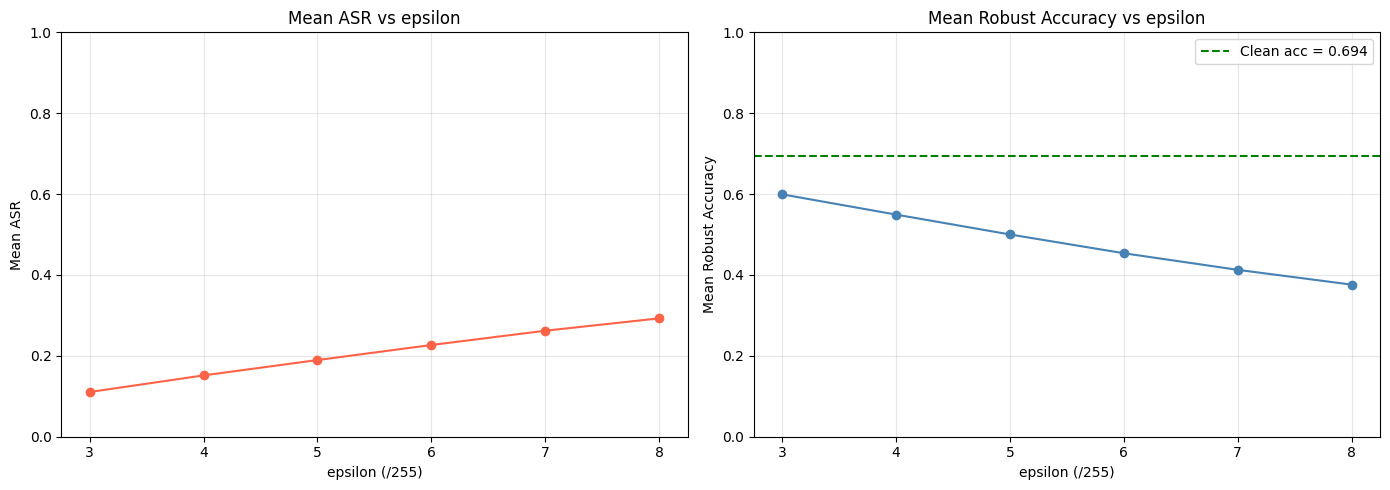

In [230]:
eps_values = [s['eps'] * 255 for s in summaries]
mean_asrs = [s['mean_asr'] for s in summaries]
mean_robs = [s['mean_robust_acc'] for s in summaries]
clean = summaries[0]['clean_acc']

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(eps_values, mean_asrs, marker='o', color='tomato')
ax[0].set_xlabel('epsilon (/255)')
ax[0].set_ylabel('Mean ASR')
ax[0].set_ylim(0, 1)
ax[0].set_title('Mean ASR vs epsilon')
ax[0].grid(alpha=0.3)

ax[1].plot(eps_values, mean_robs, marker='o', color='steelblue')
ax[1].axhline(clean, color='green', linestyle='--', label=f'Clean acc = {clean:.3f}')
ax[1].set_xlabel('epsilon (/255)')
ax[1].set_ylabel('Mean Robust Accuracy')
ax[1].set_ylim(0, 1)
ax[1].set_title('Mean Robust Accuracy vs epsilon')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

I due grafici mostrano che all'aumentare del budget, l'accuratezza del modello decresce.